# 模拟退火

考虑优化问题：

$$\min_{(x,y)\in D} f(x,y),\qquad D=[-5.12,5.12]^2$$

其中目标函数为二维 Rastrigin 函数：

$$f(x,y)=20+x^2+y^2-10[\cos(2\pi x)+\cos(2\pi y)]$$

该函数在 $(0,0)$ 处取得全局最小值 $f(0,0)=0$，但定义域内还密集分布着许多局部极小值点。先画出目标函数的曲面，观察其非凸结构。

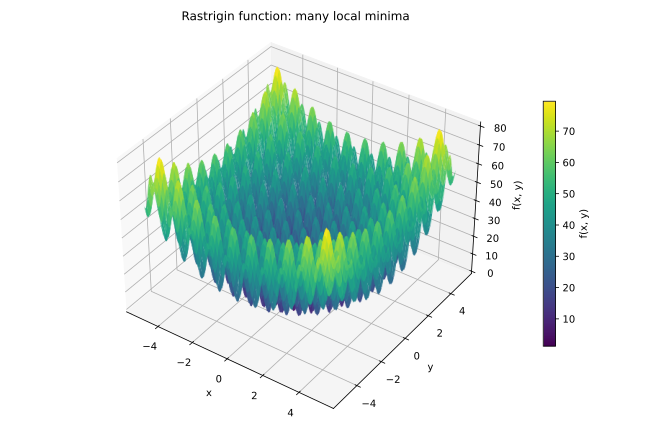

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
from simanneal import Annealer

from figure_settings import configure_matplotlib

configure_matplotlib()

LOWER_BOUND, UPPER_BOUND = -5.12, 5.12


def rastrigin(state):
    x, y = state
    return 20.0 + x**2 + y**2 - 10.0 * (
        math.cos(2.0 * math.pi * x) + math.cos(2.0 * math.pi * y)
    )


grid = np.linspace(LOWER_BOUND, UPPER_BOUND, 180)
grid_x, grid_y = np.meshgrid(grid, grid)
grid_z = 20.0 + grid_x**2 + grid_y**2 - 10.0 * (
    np.cos(2.0 * np.pi * grid_x) + np.cos(2.0 * np.pi * grid_y)
)

fig = plt.figure(figsize=(9.0, 6.0))
axis = fig.add_subplot(111, projection="3d")
surface = axis.plot_surface(
    grid_x, grid_y, grid_z, cmap="viridis", rstride=2, cstride=2,
    linewidth=0.0, antialiased=True, rasterized=True
)
axis.set(xlabel="x", ylabel="y", zlabel="f(x, y)",
         title="Rastrigin function: many local minima")
axis.view_init(elev=37, azim=-55)
fig.colorbar(surface, ax=axis, shrink=0.62, pad=0.08, label="f(x, y)")
fig.tight_layout()
plt.show()

## 使用 `simanneal` 求解

取初始解 $x_0=(4.5,4.5)$，并使用以下机制：

- **候选解生成机制：** 每次等概率选择一个坐标，在该坐标上加入标准差为 $0.18$ 的 Gaussian 扰动；若扰动后的坐标越过 $D$ 的边界，则将其反射回可行域。
- **退火机制：** 使用 `simanneal` 的指数降温。设总迭代次数为 $K$，则第 $k$ 次迭代的温度为：

  $$T_k=T_{\max}\exp\left[-\frac{k}{K}\log\left(\frac{T_{\max}}{T_{\min}}\right)\right]$$

  其中 $T_{\max}=30$，$T_{\min}=10^{-4}$，$K=60000$。对候选解产生的目标函数增量 $\Delta$，当 $\Delta\leqslant0$ 时直接接受；当 $\Delta>0$ 时，以概率 $\exp(-\Delta/T_k)$ 接受。

下面的类只定义目标函数与候选解的生成方式；Metropolis 接受规则和指数降温由 `simanneal.Annealer` 实现。

In [2]:
INITIAL_STATE = [4.5, 4.5]
STEP_SCALE = 0.18
ANNEALING_STEPS = 60_000


def reflect_to_domain(value):
    # 边界处理：把越过边界的坐标反射回可行域，而不是直接截断。
    while value < LOWER_BOUND or value > UPPER_BOUND:
        if value < LOWER_BOUND:
            value = 2.0 * LOWER_BOUND - value
        if value > UPPER_BOUND:
            value = 2.0 * UPPER_BOUND - value
    return value


class RastriginAnnealer(Annealer):
    copy_strategy = "slice"

    def __init__(self, initial_state):
        self.history = []
        super().__init__(initial_state)

    def move(self):
        # 候选解生成机制：随机选择一个坐标，并加入 N(0, 0.18^2) 扰动。
        coordinate = random.randrange(2)
        proposal = self.state[coordinate] + random.gauss(0.0, STEP_SCALE)
        self.state[coordinate] = reflect_to_domain(proposal)

    def energy(self):
        return rastrigin(self.state)

    def update(self, step, temperature, energy, acceptance, improvement):
        # 每隔固定迭代数记录当前解；不调用默认 update，以免打印进度表。
        self.history.append(
            {
                "step": step,
                "temperature": temperature,
                "energy": energy,
                "best_energy": self.best_energy,
                "x": self.state[0],
                "y": self.state[1],
            }
        )


# 退火机制：simanneal 在 Tmax 与 Tmin 之间按指数规律降温，并使用
# Metropolis 概率 exp(-Delta/T) 决定是否接受目标函数上升的候选解。
random.seed(19)
annealer = RastriginAnnealer(INITIAL_STATE)
annealer.Tmax = 30.0
annealer.Tmin = 1.0e-4
annealer.steps = ANNEALING_STEPS
annealer.updates = 3_000
best_state, best_energy = annealer.anneal()

best_state = np.asarray(best_state)
history = {
    key: np.asarray([record[key] for record in annealer.history])
    for key in annealer.history[0]
}
print(f"Best state: {best_state}")
print(f"Best objective value: {best_energy:.8g}")

Best state: [-1.51453786e-05 -2.79294234e-05]
Best objective value: 2.0026395e-07


## 解的移动与目标函数值的下降

左图在目标函数等高线上画出当前解的移动。为避免轨迹点过密，只显示每 $300$ 次迭代的一个位置；连线仍由每 $20$ 次迭代记录的状态构成。右图同时显示当前解的目标函数值和迄今为止找到的最优值：高温阶段允许当前值暂时上升，而最优值保持单调不增。

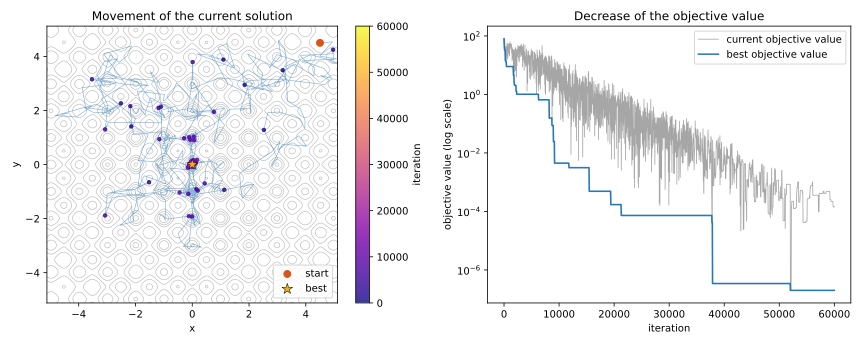

In [3]:
contour_levels = [1, 5, 10, 15, 20, 30, 40, 50, 60, 80]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

axes[0].contour(
    grid_x, grid_y, grid_z, levels=contour_levels, colors="0.72", linewidths=0.6
)
axes[0].plot(history["x"], history["y"], color="#2878B5",
             linewidth=0.65, alpha=0.55)
sample = slice(None, None, 15)
path_points = axes[0].scatter(
    history["x"][sample], history["y"][sample],
    c=history["step"][sample], cmap="plasma", s=12, alpha=0.8, zorder=3
)
axes[0].scatter(*INITIAL_STATE, marker="o", s=48, color="#D95319",
                label="start", zorder=4)
axes[0].scatter(*best_state, marker="*", s=125, color="#EDB120",
                edgecolor="black", linewidth=0.5, label="best", zorder=5)
axes[0].set(
    xlim=(LOWER_BOUND, UPPER_BOUND), ylim=(LOWER_BOUND, UPPER_BOUND),
    xlabel="x", ylabel="y", title="Movement of the current solution"
)
axes[0].legend(loc="lower right")
fig.colorbar(path_points, ax=axes[0], label="iteration")

positive_floor = 1.0e-7
axes[1].semilogy(
    history["step"], np.maximum(history["energy"], positive_floor),
    color="0.65", linewidth=0.8, label="current objective value"
)
axes[1].semilogy(
    history["step"], np.maximum(history["best_energy"], positive_floor),
    color="#2878B5", linewidth=1.6, label="best objective value"
)
axes[1].set(
    xlabel="iteration", ylabel="objective value (log scale)",
    title="Decrease of the objective value"
)
axes[1].legend()

fig.tight_layout()
plt.show()

## 结果说明

搜索初期的温度较高，当前解能够接受一部分目标函数值上升的移动，因此轨迹可以离开初始点附近的局部极小区域，并在多个盆地之间探索。随着温度按指数规律降低，劣化移动越来越难被接受，搜索逐渐集中到已经发现的低目标函数值区域。本次固定随机种子的运行最终到达原点附近，所得最优目标函数值接近理论最小值 $0$。